# VGG Transfer Learning

### Imports

In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets

# statistical visualization
import matplotlib.pyplot as plt
import seaborn as sns

# dataset handling 
from torch.utils.data import DataLoader

# image utils
from PIL import Image

# additional utils (array, sys)
import numpy as np
import json
import os

### Transformation for Train & Test Set

In [2]:
# Define transformations for training and validation sets

# composing transformation, chain different transformation to do on top of train and test (augmentation)
transform = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # based on mean and std dev
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
}

### Loading the Dataset with Dataloaders

In [3]:
# Load the Flowers dataset (plus transformation)
train_dataset = datasets.ImageFolder(root='./dataset/train', transform=transform['train'])
val_dataset = datasets.ImageFolder(root='./dataset/test', transform=transform['test'])

# Load by data loader with batch size 
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### Pretrained Model Loading

In [4]:
# Load a pretrained VGG-16 model
model = models.vgg16(pretrained=True)

# Freeze all layers except the final fully connected layer
for param in model.features.parameters():
    param.requires_grad = False

# Modify the classifier to train only the last layer
num_features = model.classifier[6].in_features
# redefine the final dense layer 
model.classifier[6] = nn.Linear(num_features, len(train_dataset.classes))

/home/ale/anaconda3/envs/nn/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ale/anaconda3/envs/nn/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Setting Up the Loss & Optimizer

In [5]:
# summary library
from torchsummary import summary

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
# optimize only over the final layer paramters
optimizer = optim.Adam(model.classifier[6].parameters(), lr=0.001)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

### Define the Training Loop with Validation

In [6]:
# Training function
# (loop with validation)
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    # initialize variable to track loss and accuracy
    train_losses, val_losses, val_accuracies = [], [], []
    best_accuracy = 0.0

    # iterate over the epoch (once specified the frozen layers, everything is the same)
    for epoch in range(epochs):
        # model in train mode 
        model.train()
        running_loss = 0.0
        # iterate over dataset in the data loader 
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))

        # Once training is done, validation is performed to check performances 
        # Validation phase
        model.eval()
        val_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_losses.append(val_loss / len(val_loader))
        val_accuracy = correct / total
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accuracy:.4f}")

        # Save the best model (only saving the best version based on validation accuracy)
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            torch.save(model.state_dict(), 'best_model.pth')
            print("Model checkpoint saved!")

    return train_losses, val_losses, val_accuracies

### Start Training

Epoch 1/2, Train Loss: 0.2844, Val Loss: 0.1520, Val Acc: 0.9231
Model checkpoint saved!
Epoch 2/2, Train Loss: 0.2002, Val Loss: 0.1490, Val Acc: 0.9286
Model checkpoint saved!


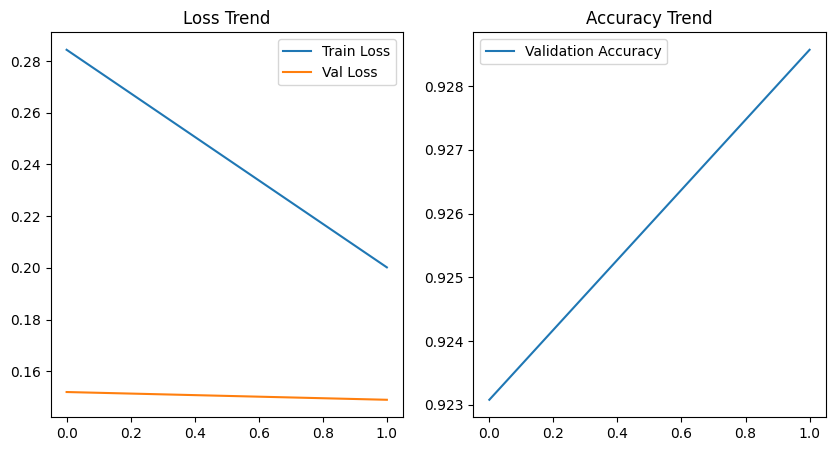

In [7]:
# Train the model (using previosuly defined function)
train_losses, val_losses, val_accuracies = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=2)

# Plot accuracy and loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss Trend')

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Trend')
plt.show()

### Load the trained Model & Evalaute

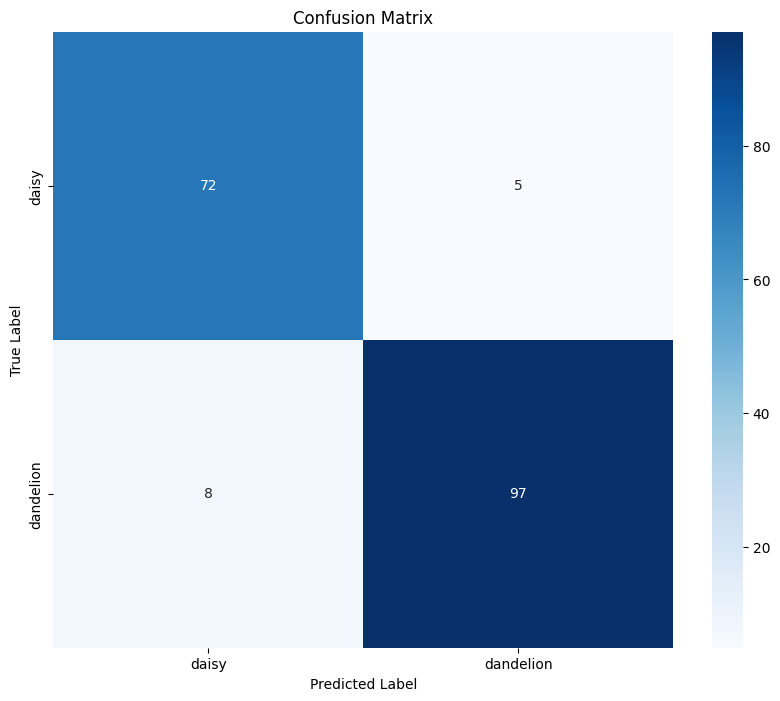

In [8]:
# Load the best model from the one saved before 
model.load_state_dict(torch.load('best_model.pth'))
# evaulation operation on best model 
model.eval()

# Inferencing
# Confusion matrix visualization
def plot_confusion_matrix(model, dataloader):
    from sklearn.metrics import confusion_matrix
    import pandas as pd

    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(model, val_loader)

### Model Inferencing

In [ ]:
# Inference function
# using the model to predict a new image ! 
def infer(image_path, model):
    image = Image.open(image_path).convert('RGB')
    image = transform['test'](image).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad(): # no gradient accumulation during inferencing 
        output = model(image)
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    # Get the top k probabilities, where k is the minimum between 5 and the number of classes
    k = min(5, probabilities.size(0))  # Ensure k is within the valid range
    top5_prob, top5_catid = probabilities.topk(k)

    # convert in string classes 
    results = [(train_dataset.classes[catid], prob.item()) for catid, prob in zip(top5_catid, top5_prob)]
    return results

In [10]:
# visualization utility 
from PIL import Image
import matplotlib.pyplot as plt

def show_image(image_path):
    image = Image.open(image_path)  # Open the image using PIL
    plt.imshow(image)  # Display the image
    plt.axis("off")  # Hide axes for better visualization
    plt.show()  # Show the image in the notebook

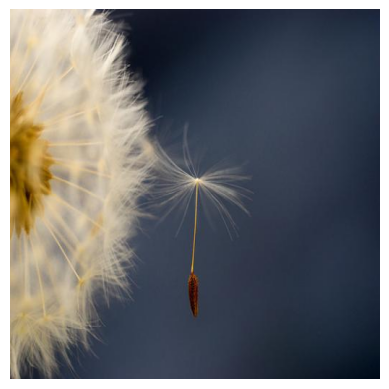

dandelion: 0.9992
daisy: 0.0008


In [13]:
# Example usage
image_path = "./dataset/test/dandelion/461632542_0387557eff_jpg.rf.f66aef4fc0a966a83d804e9b819a8db3.jpg"  # Replace with your image path
show_image(image_path)
results = infer(image_path, model)
for label, prob in results:
    print(f"{label}: {prob:.4f}")